# Elliptic Bitcoin Transaction Classification

This notebook covers data checks, exploratory analysis, graph-degree feature
engineering, chronological validation, final LightGBM training, and submission
generation.

The final model uses 164 supplied numeric features, excluding `feat_53`, plus
in-degree, out-degree, and total degree. It trains for 100 boosting rounds on
all labeled training rows.

Place `train.csv`, `test.csv`, `txs_edgelist.csv`, and `sample_submission.csv`
in `/content/drive/MyDrive/Kaggle`. Install the dependencies listed in
`requirements.txt`, restart the runtime, and run all cells in order.

The notebook saves `submission_without_feat53.csv` and
`final_lgb_model_without_feat53.txt` in the current working directory.
The saved model file is optional.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Data
train = pd.read_csv("/content/drive/MyDrive/Kaggle/train.csv")
test = pd.read_csv("/content/drive/MyDrive/Kaggle/test.csv")
edges = pd.read_csv("/content/drive/MyDrive/Kaggle/txs_edgelist.csv")

feature_cols = [c for c in train.columns if c.startswith("feat_")]

print("train schema:")
print(train.dtypes)
print("\ntest schema:")
print(test.dtypes)
print("\nedges schema:")
print(edges.dtypes)

print(f"\ntrain: {train.shape}, test: {test.shape}, edges: {edges.shape}")
print(f"# feature columns: {len(feature_cols)}")

train.head()

train schema:
txId           int64
time_step      int64
feat_1       float64
feat_2       float64
feat_3       float64
              ...   
feat_162     float64
feat_163     float64
feat_164     float64
feat_165     float64
label        float64
Length: 168, dtype: object

test schema:
index          int64
txId           int64
time_step      int64
feat_1       float64
feat_2       float64
              ...   
feat_161     float64
feat_162     float64
feat_163     float64
feat_164     float64
feat_165     float64
Length: 168, dtype: object

edges schema:
txId1    int64
txId2    int64
dtype: object

train: (141772, 168), test: (15329, 168), edges: (234355, 2)
# feature columns: 165


,txId,time_step,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,...,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165,label
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,NaN
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,NaN
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,NaN
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0.0
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,NaN


In [4]:
# Counting null values across all columns
total = len(train)
null_pcts = (train.isnull().sum() / total * 100).round(2)
print("Null percentage per column:")
print(null_pcts[null_pcts > 0].sort_values(ascending=False))

## Target Variable: Label Distribution

label_counts = train["label"].value_counts(dropna=False)
print("Label counts:")
print(label_counts)
print("\nAs fraction of total rows:")
print((label_counts / total).round(4))

labeled = train[train["label"].isin([0, 1])]
print(f"\nLabeled rows: {len(labeled)} / {total} ({len(labeled)/total:.1%})")

illicit_rate = labeled["label"].mean()
print(f"Illicit rate among LABELED rows: {illicit_rate:.4f}")
print(f"Imbalance ratio (licit:illicit): {(1 - illicit_rate) / illicit_rate:.1f} : 1")

Null percentage per column:
label    77.97
dtype: float64
Label counts:
label
NaN    110537
0.0     27591
1.0      3644
Name: count, dtype: int64

As fraction of total rows:
label
NaN    0.7797
0.0    0.1946
1.0    0.0257
Name: count, dtype: float64

Labeled rows: 31235 / 141772 (22.0%)
Illicit rate among LABELED rows: 0.1167
Imbalance ratio (licit:illicit): 7.6 : 1


In [5]:
## Temporal Structure: train vs test time_step coverage

print(f"train time_step range: {train['time_step'].min()} - {train['time_step'].max()}")
print(f"test  time_step range: {test['time_step'].min()} - {test['time_step'].max()}")

overlap = set(train["time_step"]) & set(test["time_step"])
print(f"Overlapping time_steps: {len(overlap)} "
      f"{'WARNING' if overlap else '(none, as expected)'}")

# Volume and illicit rate by time_step
n_by_time = train.groupby("time_step").size().rename("n_tx")
labeled_n_by_time = labeled.groupby("time_step").size().rename("n_labeled")
label_by_time = labeled.groupby("time_step")["label"].mean().rename("illicit_rate")

time_summary = pd.concat([n_by_time, labeled_n_by_time, label_by_time], axis=1)
time_summary

train time_step range: 1 - 35
test  time_step range: 36 - 49
Overlapping time_steps: 0 (none, as expected)


,n_tx,n_labeled,illicit_rate
time_step,,,
1,7880,2147,0.007918
2,4544,1117,0.016115
3,6621,1279,0.008600
4,5693,1440,0.020833
5,6803,1882,0.004251
6,4328,485,0.010309
7,6048,1203,0.084788
8,4457,1165,0.057511
9,4996,778,0.318766


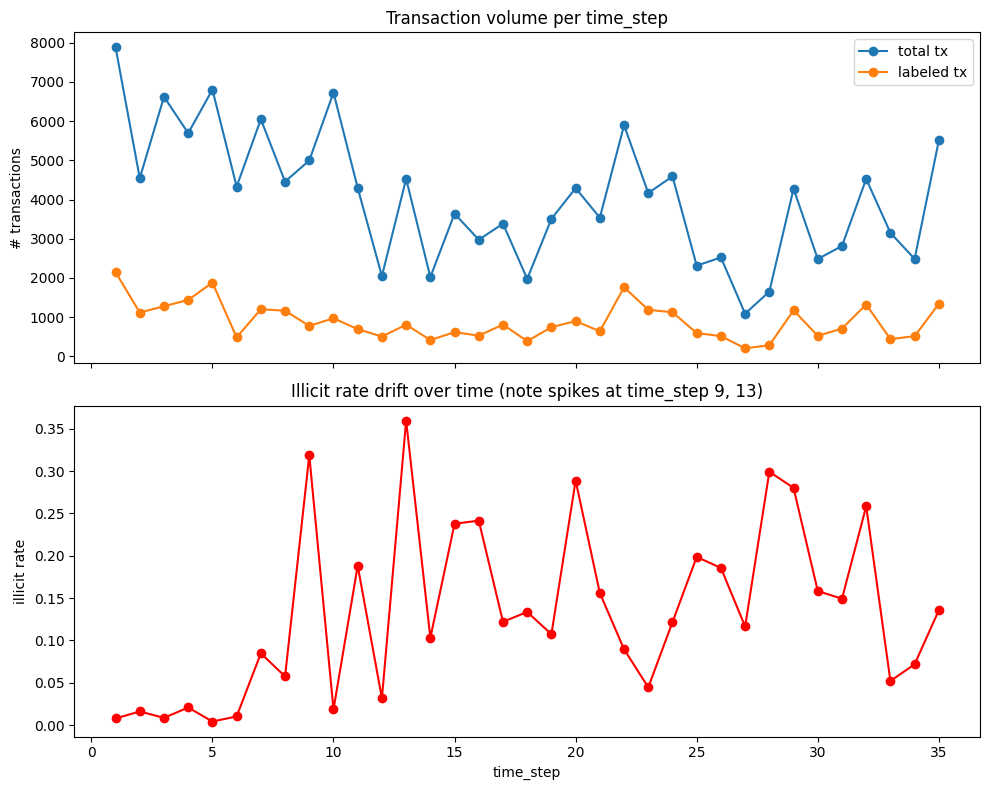

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
time_summary["n_tx"].plot(ax=axes[0], marker="o", label="total tx")
time_summary["n_labeled"].plot(ax=axes[0], marker="o", label="labeled tx")
axes[0].set_ylabel("# transactions")
axes[0].legend()
axes[0].set_title("Transaction volume per time_step")

time_summary["illicit_rate"].plot(ax=axes[1], marker="o", color="red")
axes[1].set_ylabel("illicit rate")
axes[1].set_xlabel("time_step")
axes[1].set_title("Illicit rate drift over time (note spikes at time_step 9, 13)")
plt.tight_layout()
plt.show()

In [7]:
## Graph / Edge Structure

out_deg = edges.groupby("txId1").size()
in_deg = edges.groupby("txId2").size()

print(f"# unique source tx: {edges['txId1'].nunique()}")
print(f"# unique dest tx:   {edges['txId2'].nunique()}")
print(f"Total edges: {len(edges)}")

print("\nOut-degree stats:")
print(out_deg.describe())
print("\nIn-degree stats:")
print(in_deg.describe())

print("\nTop 10 highest out-degree tx (distribution to subsequent transactions):")
print(out_deg.sort_values(ascending=False).head(10))

print("\nTop 10 highest in-degree tx (consolidation from predecessor transactions):")
print(in_deg.sort_values(ascending=False).head(10))

# unique source tx: 166345
# unique dest tx:   148447
Total edges: 234355

Out-degree stats:
count    166345.000000
mean          1.408849
std           2.008279
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         472.000000
dtype: float64

In-degree stats:
count    148447.000000
mean          1.578712
std           4.507890
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         284.000000
dtype: float64

Top 10 highest out-degree tx (distribution to subsequent transactions):
txId1
2984918    472
89273      288
102570     122
3181       112
7952        99
1891081     95
143705      92
565334      90
488266      88
793584      82
dtype: int64

Top 10 highest in-degree tx (consolidation from predecessor transactions):
txId2
43388675     284
68705820     247
30699343     241
96576418     239
225859042    212
279187194    211
234890810    199
196107869    188
43397277     182
68706499     1

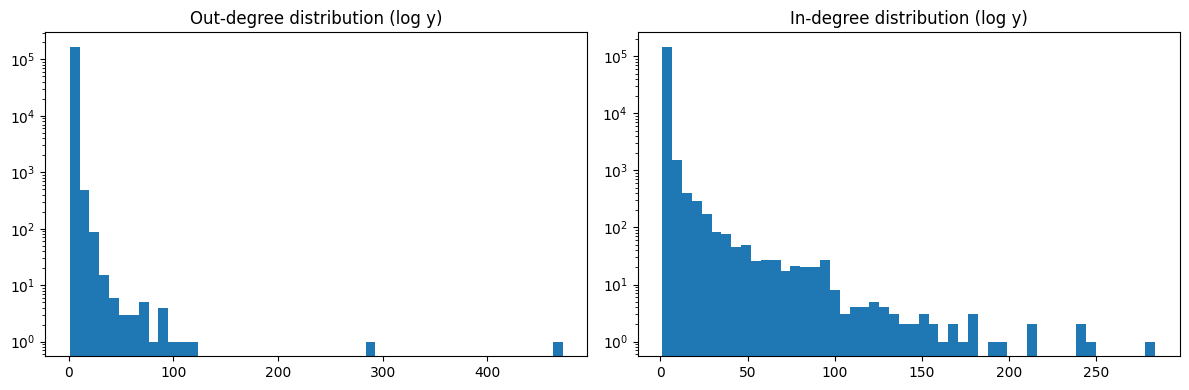

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(out_deg, bins=50, log=True)
axes[0].set_title("Out-degree distribution (log y)")
axes[1].hist(in_deg, bins=50, log=True)
axes[1].set_title("In-degree distribution (log y)")
plt.tight_layout()
plt.show()

## Feature Engineering

In [9]:
## Graph feature engineering

def add_graph_features(df, out_deg, in_deg):
    df = df.copy()
    df["out_deg"] = df["txId"].map(out_deg).fillna(0)
    df["in_deg"] = df["txId"].map(in_deg).fillna(0)
    df["total_deg"] = df["out_deg"] + df["in_deg"]
    return df

# NOTE: column engineering happens BEFORE any train/val split below,
# so the split copies inherit these columns.
train = add_graph_features(train, out_deg, in_deg)
test = add_graph_features(test, out_deg, in_deg)

train[["txId", "out_deg", "in_deg", "total_deg"]].head()

,txId,out_deg,in_deg,total_deg
0,230425980,1.0,1.0,2.0
1,5530458,1.0,1.0,2.0
2,232022460,2.0,1.0,3.0
3,232438397,1.0,160.0,161.0
4,230460314,8.0,2.0,10.0


## Validation Strategy

Train on labeled periods 1–30 and validate on periods 31–35 using ROC-AUC.
This holdout has been used for model selection; its score is not an independent
estimate of performance on the later test periods.

In [10]:
## Time-based train/validation split
# Test time_steps come strictly after train time_steps, so we mimic that
# chronological ordering locally rather than mixing time periods in random folds.

val_time_steps = sorted(train["time_step"].unique())[-5:]  # last 5 time_steps as validation
train_mask = ~train["time_step"].isin(val_time_steps)

X_train_raw = train[train_mask]
X_val_raw = train[~train_mask]

print(f"Train time_steps: {sorted(X_train_raw['time_step'].unique())}")
print(f"Val time_steps:   {sorted(X_val_raw['time_step'].unique())}")
print(f"Train rows: {len(X_train_raw)}, Val rows: {len(X_val_raw)}")
print(f"Has graph features: {'out_deg' in X_train_raw.columns}")

Train time_steps: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Val time_steps:   [np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35)]
Train rows: 123287, Val rows: 18485
Has graph features: True


In [11]:
## Baseline Model: prep train/val matrices

import lightgbm as lgb
from sklearn.metrics import roc_auc_score

# only use labeled rows for training/validation
labeled_train = X_train_raw[X_train_raw["label"].isin([0, 1])].copy()
labeled_val = X_val_raw[X_val_raw["label"].isin([0, 1])].copy()

model_feature_cols = [c for c in feature_cols if c != "feat_53"] + ["out_deg", "in_deg", "total_deg"]

X_tr = labeled_train[model_feature_cols]
y_tr = labeled_train["label"]
X_va = labeled_val[model_feature_cols]
y_va = labeled_val["label"]

print(f"Train: {X_tr.shape}, illicit rate: {y_tr.mean():.4f}")
print(f"Val:   {X_va.shape}, illicit rate: {y_va.mean():.4f}")

Train: (26905, 167), illicit rate: 0.1098
Val:   (4330, 167), illicit rate: 0.1594


## Validation integrity checks

Check transaction-ID separation, chronological ordering, and exact feature-row
matches across the training and validation partitions. These checks catch specific
problems; they do not establish the provenance of anonymized features or prove
the absence of all leakage. Graph degree features use the supplied edge list
without labels, consistent with the provided graph-feature setup.

In [12]:
# Check for exact feature matches across partitions, not duplicates within one partition.
train_patterns = X_tr.drop_duplicates()
validation_matches = X_va.merge(
    train_patterns, on=model_feature_cols, how="left", indicator=True,
    validate="many_to_one",
)
n_matches = int(validation_matches["_merge"].eq("both").sum())
print(f"Validation rows with an exact feature match in training: {n_matches}")
if n_matches:
    print("Review matching rows before interpreting validation performance.")

assert set(labeled_train["txId"]).isdisjoint(labeled_val["txId"])
assert set(train["txId"]).isdisjoint(test["txId"])
assert X_train_raw["time_step"].max() < X_val_raw["time_step"].min()
assert train["time_step"].max() < test["time_step"].min()
assert y_tr.nunique() == 2 and y_va.nunique() == 2
print("Transaction IDs and temporal boundaries are separated.")

Validation rows with an exact feature match in training: 0
Transaction IDs and temporal boundaries are separated.


In [13]:
## Train LightGBM (validation run)
pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
lgb_train = lgb.Dataset(X_tr, label=y_tr)

params = {
    "objective": "binary",
    "metric": "auc",
    "scale_pos_weight": pos_weight,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "verbose": -1,
}

val_model = lgb.train(params, lgb_train, num_boost_round=100)
val_preds = val_model.predict(X_va, num_iteration=100)
val_auc = roc_auc_score(y_va, val_preds)
print(f"Validation AUC: {val_auc:.5f}")

Validation AUC: 0.99723


In [14]:
# Baseline feature importance (descriptive, not a leakage test)

importance = pd.DataFrame({
    "feature": model_feature_cols,
    "importance": val_model.feature_importance(importance_type="gain"),
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
40,feat_41,88931.166651
57,feat_59,83981.254661
53,feat_55,72089.085417
56,feat_58,41411.649169
1,feat_2,35788.359734
4,feat_5,31075.170033
99,feat_101,18323.730343
98,feat_100,16258.702695
101,feat_103,16166.070582
74,feat_76,10862.428127


## Final Model: Retrain on All Labeled Data

Train on all labeled rows using 164 numeric features, excluding `feat_53`,
and the three degree features. Keep the selected training length fixed at 100 rounds.

In [15]:
## Retrain on full labeled train data (no holdout) for final submission

labeled_full = train[train["label"].isin([0, 1])].copy()

X_full = labeled_full[model_feature_cols]
y_full = labeled_full["label"]

full_pos_weight = (y_full == 0).sum() / (y_full == 1).sum()

lgb_full_train = lgb.Dataset(X_full, label=y_full)

final_params = {
    "objective": "binary",
    "metric": "auc",
    "scale_pos_weight": full_pos_weight,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "verbose": -1,
}

# Fixed training length selected in the round-count experiment
final_num_rounds = 100

final_model = lgb.train(
    final_params,
    lgb_full_train,
    num_boost_round=final_num_rounds,
)

print(f"Final model trained on {len(X_full)} rows for {final_num_rounds} rounds.")

## Save the final model artifact

final_model.save_model("final_lgb_model_without_feat53.txt")
print("Model saved to final_lgb_model_without_feat53.txt")

Final model trained on 31235 rows for 100 rounds.
Model saved to final_lgb_model_without_feat53.txt


In [16]:
## Generate test predictions and submission file (using FINAL model)

X_test = test[model_feature_cols]
test_preds = final_model.predict(X_test)

submission = pd.DataFrame({
    "index": test["index"],
    "target": test_preds,
})
print(submission.head())
print(f"\nSubmission shape: {submission.shape}")

   index    target
0      0  0.002248
1      1  0.009307
2      2  0.009750
3      3  0.003280
4      4  0.002740

Submission shape: (15329, 2)


## Submission Format Sanity Checks

In [17]:
# Validate the full submission against the supplied template and test IDs.
sample_sub = pd.read_csv("/content/drive/MyDrive/Kaggle/sample_submission.csv")
assert submission.columns.tolist() == sample_sub.columns.tolist() == ["index", "target"]
assert len(submission) == len(test) == len(sample_sub)
assert submission["index"].is_unique
assert submission["index"].equals(test["index"])
assert submission["index"].equals(sample_sub["index"])
assert np.isfinite(submission["target"]).all()
assert submission["target"].between(0, 1).all()
print(submission["target"].describe())
print(f"Unique prediction values: {submission['target'].nunique()}")

# Write only after all format checks pass.
submission.to_csv("submission_without_feat53.csv", index=False)
print(f"Saved submission_without_feat53.csv: {len(submission)} rows; all checks passed.")

count    15329.000000
mean         0.075363
std          0.205620
min          0.000808
25%          0.001469
50%          0.005618
75%          0.031458
max          0.993868
Name: target, dtype: float64
Unique prediction values: 12605
Saved submission_without_feat53.csv: 15329 rows; all checks passed.
